# Создание рекомендательной системы товаров

Данный файл содержит краткое описание построения рекомендательной системы.\
И ссылки на файлы, где это построение происходит.

## Импорт библиотек

In [28]:
import sys
# Добавим папку проекта в список системных директорий, чтобы Python видел путь к папке rec_sys
sys.path.append("../../")

In [ ]:
import pandas as pd

from rec_sys.utils.graphs import show_pie

# Путь к папке с данными
DATA_PATH = "../../data"

## Описание задачи

Находится в файле [README](../../README.md).

## Описание данных

У нас есть таблицы с данными о продажах товаров некоторого маркетплейса.

### Таблица с событиями `events.csv`

**Описание признаков:**

- `timestamp` — время события
- `visitorid` — идентификатор пользователя
- `event` — тип события
    - `view` - просмотр
    - `addtocart` - добавление в корзину
    - `transaction` - транзакция (покупка)
- `itemid` — идентификатор товара
- `transactionid` — идентификатор транзакции, если она проходила

In [30]:
# Данные о событиях
events_data = pd.read_csv(f"{DATA_PATH}/events.csv")

print("Размерность таблицы:", events_data.shape)

events_data.head()

Размерность таблицы: (2756101, 5)


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [31]:
# Посмотрим на типы данных
events_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


### Таблица с деревом категорий `category_tree.csv`

**Описание признаков:**

- `category_id` — идентификатор категорий
- `parent_id` — идентификатор родительской категории

In [32]:
# Данные о структуре каталога
category_data = pd.read_csv(f"{DATA_PATH}/category_tree.csv")

print("Размерность таблицы:", category_data.shape)

category_data.head()

Размерность таблицы: (1669, 2)


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


In [33]:
# Посмотрим на типы данных
category_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


### Таблицы со свойствами товаров `item_properties_part1.csv`, `item_properties_part2.csv`

**Описание признаков:**

- `timestamp` — момент записи значения свойства
- `item_id` — идентификатор товара
- `property` — идентификатор свойства (может содержать буквы)
- `value` — значение свойства

Загрузим эти таблицы и посмотрим на их первые строки.

In [34]:
# Данные о товарах
item_properties_data = pd.concat([
    pd.read_csv(f"{DATA_PATH}/item_properties_part1.csv"),
    pd.read_csv(f"{DATA_PATH}/item_properties_part2.csv")
])

print("Размерность таблицы:", item_properties_data.shape)

item_properties_data.head()

Размерность таблицы: (20275902, 4)


,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [35]:
# Посмотрим на типы данных
item_properties_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20275902 entries, 0 to 9275902
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 773.5+ MB


## Исследование данных

Вынесено в файл [02_eda.ipynb](./02_eda.ipynb)

**В кратце, что существенного для дальнейших действий мы там выяснили.**

- Данные представлены примерно за 4.5 месяца (май - сентябрь 2015г).
- У нас очень мало транзакций по сравнению с просмотрами и добавлениями в корзину.

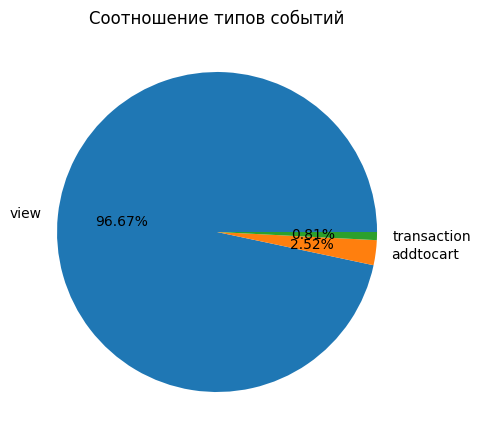

In [ ]:
show_pie(events_data, "event", "Соотношение типов событий")

- Наиболее популярные товары в разные месяцы различаются.

- Активность пользователей зависит от времени суток и дня недели.

- В каждом следующем месяце на сайт заходит только 4-5% посетителей из прошлого месяца. \
Количество посетителей, которые заходили на сайт в каждом месяце, менее 1%.

- В каждом следующем месяце покупается 20-25% товаров из прошлого месяца.\
Количество постоянных товаров, которые покупали в каждом месяце, менее 1%.

- Таблица с категориями `category_data` содержит 25 корневых разделов и 1669 уникальных категорий.\
Максимальная глубина вложенности товара в каталог - 6.

- Таблица со свойствами товаров (`item_properties_data`) в поле `property` содержит некоторые данные, \
которые можнно использовать как свойства товаров, в частности:
    - значения по ключу "`790`" очень похожи на цену товара.
    - значения по ключу "`categoryid`" представляют из себя категорию из таблицы `category_data`.
    - значения по ключу "`available`" скорее всего представляют из себя некий вид доступности товара.

Все это можно использовать для создания признаков.

## Создание признаков

Вынесено в файл [03_feature_engineering](./03_feature_engineering)

Здесь мы разделили данные с событиями `events_data` на тренировочную и тестовую выборки \
в соотношении примерно 70% : 30 %.

На основании тренировочной выборки из `events_data` и всех данных о товарах создали 2 таблицы:

- `users_data` с данными пользователей.
- `items_data` с данными товаров;

### Таблица с данными пользователей `users_data.csv`

In [41]:
users_data = pd.read_csv(f"{DATA_PATH}/users_data.csv")

print("Размерность таблицы:", users_data.shape)

users_data.head(3)

Размерность таблицы: (972459, 66)


,visitorid,adds_count,trans_cout,views_count,min_items_in_trans,mean_items_in_trans,max_items_in_trans,adds_in_day_0,trans_in_day_0,views_in_day_0,...,trans_in_cat_803,trans_in_cat_859,trans_in_cat_1224,trans_in_cat_1452,trans_in_cat_1482,trans_in_cat_1490,trans_in_cat_1532,trans_in_cat_1579,trans_in_cat_1600,trans_in_cat_1698
0,3,0,0,0,0.0,0.0,0.0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5,0,0,0,0.0,0.0,0.0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,7,0,0,0,0.0,0.0,0.0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Здесь мы создали следующие признаки.**

- `visitorid` пользователя (это свойство у нас било изначально).
- Общее количество действий каждого типа.
    - Поля с именами `{views|adds|trans}_count`
- Максимальное, минимальное и среднее количество товаров в одной покупке \
(одна покупка определяется по уникальному номеру транзакции в `transactionid`).
    - Поля с именами `{max|min|mean}_items_in_trans`
- Количество действий каждого типа  в каждый день недели.
    - Поля с именами `{views|adds|trans}_in_day_{0|1|2|3|4|5|6}`
- Количество действий каждого типа в каждое время дня.
    - Поля с именами `{views|adds|trans}_in_time_{3-7|7-12|12-16|16-22|22-3}`
- Количество купленных товаров с `available == 0`.
    - Поле `trans_available_0`
- Средняя и медианная стоимость всех купленных товаров (`price`).
    - Поля с именами `{mean|median}_check`.
- Количество купленных товаров с ценой 0 (`is_price_0`).
    - Поле `trans_price_0`.
- Количество купленных товаров в каждой корневой категории каталога.
    - Поля с именами `trans_in_cat_{id_каталога}`. \
    Корневых категорий 25, но полей у нас 19, т.к. не все категории покупали.

### Таблица с данными товаров `items_data.csv`

In [39]:
items_data = pd.read_csv(f"{DATA_PATH}/items_data.csv")

print("Размерность таблицы:", items_data.shape)

items_data.head(3)

Размерность таблицы: (417053, 315)


,itemid,is_top_10,trans_in_day_0,trans_in_day_1,trans_in_day_2,trans_in_day_3,trans_in_day_4,trans_in_day_5,trans_in_day_6,trans_in_time_12-16,...,c_291,c_292,c_293,c_294,c_295,c_296,c_297,c_298,c_299,c_300
0,0,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.910129e-07,0.000138,-0.000066,-0.000154,-0.000102,0.000198,-0.000086,-0.000079,0.000069,-0.000041
1,1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.069498e-07,0.000179,-0.000086,-0.000200,-0.000131,0.000256,-0.000111,-0.000103,0.000089,-0.000054
2,2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.813608e-03,-0.001189,0.000129,0.006457,0.007567,-0.001437,0.004260,0.004028,0.006627,0.000051


**Здесь мы создали следующие признаки.**

- `itemid` товара (это свойство у нас было изначально).
- Входит ли в топ-10 самых покупаемых.
    - Поле `is_top_10`
- Сколько раз товар купили в каждый день недели.
    - Поля с именами `trans_in_day_{0|1|2|3|4|5|6}`
- Сколько раз товар купили в каждое время дня.
    - Поля с именами `trans_in_time_{3-7|7-12|12-16|22-3}`
- Цена товара.
    - Поле `last_price`.
- Флаги принадлежности ко всей вложенной цепочке категорий товаров. \
Этому набору признаков мы уменьшили размерность с помощью `PCA` с 1181 значений до 300.\
Осташиеся 300 признаков компонент в сумме объясняют 89% дисперсии исходного набора.
    - Эти поля имеют имена `c_{номер_компоненты}`.

**Что мы выяснили про соотношение тренировочной и тестовой выборок.**

- Процент пользователей из тестовой выборки, которых нет в тренировочной: 93.55 % 
    > То есть, на этапе прогноза у нас будет почти 94% новых пользователей, \
    данные по которым не участвовали в обучении.

- Процент товаров, которые есть в тренировочной таблице событий и отсутствуют в тестовой: 46.75 %

- Процент товаров, которые есть в тестовой таблице событий и отсутствуют в тренировочной: 24.48 %

## Создание модели

Вынесено в файл [04_create_model.ipynb](./04_create_model.ipynb)

Мы будем использовать библиотеку [rectools](https://rectools.readthedocs.io/en/latest/index.html), \
которая  предназначена для удобного подбора модели и параметров для рекомендательных систем.\
Она имеет единый интерфейс для взаимодействия с разыми моделями \
и предоставляет возможности подбора параметров для различных метрик.

Здесь эксперименты привели нас к идее создания **гибридной** рекомендательной системы. \
То есть, для разных типов пользователей мы будем генерировать рекомендации с помощью разных алгоритмов.

**Выделяем 3 группы пользователей:**

- Количество действий в тренировочной выборке больше `15` и меньше `4000`.\
Идентификатор названия группы `normal` (нормальная активность).

- Количество действий в тренировочной выборке не более `15` или больше `4000`.\
Вообще, более 4000 действий имеет только 1 пользователь, но мы все равно его выделили отдельно.\
Идентификатор названия группы `extremal` (экстремальная активность).

- Пользователи из тестовой выборки, которых не было в обучении и о которых мы ничего не знаем.\
Идентификатор названия группы `cold` (холодные пользователи).

По соотношениям разделения тренировочной выборки мы имеем следующую картину.

<img src="./images/normal_extremal_train_unique_users.png" width=800 /><br />
<img src="./images/normal_extremal_train_events_count.png" width=800 />

**Для каждой группы мы соответственно используем свою валидационную выборку.**

- `normal` \
Из тестовой выборки выделяем только тех пользователей, которые в тренировочной входили в группу `normal`.

- `extremal` \
Из тестовой выборки выделяем только тех пользователей, которые в тренировочной входили в группу `extremal`.

- `cold` \
Все пользователи тестовой выборки, которых не было в обучении.

> Таким образом, мы разделили тестовую выборку на 3 части.\
И на каждой из 3-х частей будем проверять результаты для своей группы.

По соотношениям разделения тестовой выборки мы имеем следующую картину.

<img src="./images/text_data_unique_users.png" width=800 /><br />
<img src="./images/text_data_events_count.png" width=800 />

**Как мы будем генерировать рекомендации для каждой группы.**

- `normal` \
Будем использовать модель `ALS` (Alternating Least Square, метод наименьших квадратов).\
Эта модель основана на матричной факторизации и использует матрицы признаков пользователей и товаров.

    В итоге модель выделяет похожих пользователей и рекомендует товары по принципу,\
    что если пользователи похожи, то и их вкусы могут быть похожи.\
    И если пользователь А похож на пользователя B,\
    и пользователю A понравился товар "1", но пользователь B его еще не смотрел, \
    то модель порекомендует пользователю B этот товар "1".
    
    > Такой подход к формированию рекомендаций назвается **коллаборативным**.

    ![](./images/als_for_normal.png)

    Чтобы данная модель показывала хорошие результаты, матрица взаимодействий должна быть "плотной",\
    то есть, не должно быть пользователей с редкими событиями.\
    Поэтому в результате экспериментов с количеством действий \
    и метрикой `precision@3` на кроссвалидации на тренировочной выборке \
    мы подобрали порог в 15 действий.

    > Метрика `precision@3` на тестовой выборке составила `0.699`.

- `extremal` \
Здесь мы будем составлять рекомендации на основе последней активности пользователя.\
Возьмем товар, с которым пользователь взаимодействовал в последний раз.\
Выделим несколько похожих на него товаров (опытным путем выяснилось, что лучше брать 50 штук)\
И из этих 50-ти выделим 3 товара для рекомендаций:
    - cамый близкий по метрике сходства;
    - cамый дешевый;
    - cамый покупаемый.

    > Такой подход к формированию рекомендаций носит название **контентного**.

    ![](./images/content_for_extremal.png)

    Индексировать похожие товары будем с помощью библиотеки `annoy`.

    > Метрика `precision@3` на тестовой выборке составила `0.0009`.

    Тут нужно иметь в виду, то мы не имеем данных о реальных взаимодействиях с рекомендациями.\
    Мы можем только проверить, насколько сгенерированные рекомендации совпали с тем,\
    что уже выбрали пользователи.\
    Если стремится угадать следующую покупку с целью повысить метрику, то такие рекомендации
    могут совпадать с тем, что уже видел пользователь.\
    Тут цель в попытке заинтересовать предложением.\
    Поэтому метрики низкие, но все же лучше, чем случайные (по сравнению с random-моделью).\
    Гипотеза состоит в том, что данные рекомендации заинтересуют пользователей при реальном взаимодействии.
    
    На реальном потоке данных можно брать последний товар не из тренировочной выборки, а из реальных\
    последних взаимодействий пользователя.\
    Поскольку 3 рекомендации по условию задачи предполагается размещать на главной странице,\
    то какие-то сложные агрегирующие запросы будут не очень уместны.\
    А последний товар достать быстро.\
    Также есть предположение, что если выстраивать рекомендации не по последнему товару,\
    а по тому, на который приходится наибольший вес взаимодействий пользователя,\
    то рекомендации могут залипнуть на том, что пользователь может быть активно искал, но уже купил.

> Тут надо заметить, что в первых двух случаях мы исключаем из рекомендаций просмотренные товары.\
Для самого активного пользователя с более чем 4000 действиями исключаем последние 15.

- `cold` \
Холодным пользователям будем рекомендовать самые популярные товары.

    > То есть, применим подходк к формированию рекомендаций **на основе популярности**.

    ![](./images/popular_for_cold.png)

    С помощью `rectools` удалось выяснить, что лучше рассчитывать популярность \
    на основе общего веса взаимодействий по товару \
    (параметр `popularity=sum_weight` для модели `PopularModel`) \
    и брать период расчета за последние `60` дней.

    > Метрика `precision@3` на тестовой выборке составила `0.00137`.

## Описание приложения для получения рекомендаций по API

Находится в файле [README](../../README.md).